In [273]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/uciml/iris/Iris.csv
/kaggle/input/datasets/organizations/uciml/iris/database.sqlite


In [274]:
df= pd.read_csv("/kaggle/input/datasets/organizations/uciml/iris/Iris.csv")
print(df.head)
print(df.columns)


<bound method NDFrame.head of       Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  \
0      1            5.1           3.5            1.4           0.2   
1      2            4.9           3.0            1.4           0.2   
2      3            4.7           3.2            1.3           0.2   
3      4            4.6           3.1            1.5           0.2   
4      5            5.0           3.6            1.4           0.2   
..   ...            ...           ...            ...           ...   
145  146            6.7           3.0            5.2           2.3   
146  147            6.3           2.5            5.0           1.9   
147  148            6.5           3.0            5.2           2.0   
148  149            6.2           3.4            5.4           2.3   
149  150            5.9           3.0            5.1           1.8   

            Species  
0       Iris-setosa  
1       Iris-setosa  
2       Iris-setosa  
3       Iris-setosa  
4       Iris-setosa

In [275]:
X=df.iloc[0::,1:5]
print(X)
y=df.iloc[0::,-1]
print(y)

     SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0              5.1           3.5            1.4           0.2
1              4.9           3.0            1.4           0.2
2              4.7           3.2            1.3           0.2
3              4.6           3.1            1.5           0.2
4              5.0           3.6            1.4           0.2
..             ...           ...            ...           ...
145            6.7           3.0            5.2           2.3
146            6.3           2.5            5.0           1.9
147            6.5           3.0            5.2           2.0
148            6.2           3.4            5.4           2.3
149            5.9           3.0            5.1           1.8

[150 rows x 4 columns]
0         Iris-setosa
1         Iris-setosa
2         Iris-setosa
3         Iris-setosa
4         Iris-setosa
            ...      
145    Iris-virginica
146    Iris-virginica
147    Iris-virginica
148    Iris-virginica
149    Iris-

In [276]:
y=df.iloc[0::,-1]
print(y)

0         Iris-setosa
1         Iris-setosa
2         Iris-setosa
3         Iris-setosa
4         Iris-setosa
            ...      
145    Iris-virginica
146    Iris-virginica
147    Iris-virginica
148    Iris-virginica
149    Iris-virginica
Name: Species, Length: 150, dtype: object


In [277]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit ONLY on training data, then transform all sets
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# reconvert to tensors after scaling
X_train = torch.FloatTensor(X_train)
X_val   = torch.FloatTensor(X_val)
X_test  = torch.FloatTensor(X_test)

In [278]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
y=le.fit_transform(y)
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [279]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X.values,y,test_size=0.2,random_state=45)



In [280]:
X_val,X_train_new,y_val,y_train_new=train_test_split(X_train,y_train,test_size=0.2,random_state=45)

In [281]:
import torch
import torch.nn as nn
import torch.nn.functional as func

In [282]:
X_train=torch.FloatTensor(X_train)
X_val=torch.FloatTensor(X_val)
X_test=torch.FloatTensor(X_test)
y_train=torch.LongTensor(y_train)
y_val=torch.LongTensor(y_val)
y_test=torch.LongTensor(y_test)

In [283]:
#creating a model class 
class MODEL(nn.Module):
    def __init__(self,input_features=4,h1=8,h2=7,output_layer=3):
        super().__init__()
        self.network=nn.Sequential(
        nn.Linear(input_features,h1),
        nn.ReLU(),
        nn.Linear(h1,h2),
        nn.ReLU(),
        nn.Linear(h2,output_layer)    
        )
    def forward(self,x):
       out=self.network(x)
       return out

In [284]:
model=MODEL()

In [285]:
criterion=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.parameters(),lr=0.01)

Epoch 0  Loss: 1.1044
Epoch 10  Loss: 1.0498
Epoch 20  Loss: 0.9182
Epoch 30  Loss: 0.7392
Epoch 40  Loss: 0.6582
Epoch 50  Loss: 0.5852
Epoch 60  Loss: 0.4958
Epoch 70  Loss: 0.3968
Epoch 80  Loss: 0.2725
Epoch 90  Loss: 0.1563


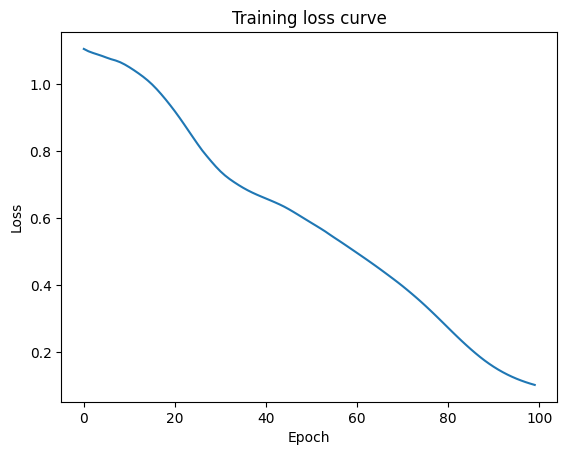

In [286]:
epochs=100
losses=[]
for epoch in range(epochs):
    model.train()
    #forward pass 
    y_pred=model.forward(X_train)
    loss=criterion(y_pred,y_train)
    #computing the backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if epoch % 10 == 0:
        print(f'Epoch {epoch}  Loss: {loss.item():.4f}')
import matplotlib.pyplot as plt
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training loss curve')
plt.show()               

In [287]:
model.eval()

with torch.no_grad():
    y_test_pred = model(X_test)
    test_loss   = criterion(y_test_pred, y_test)

    # get predicted class (highest score wins)
    predicted = torch.argmax(y_test_pred, dim=1)
    accuracy  = (predicted == y_test).float().mean()

    print(f'Test loss: {test_loss:.4f}')
    print(f'Accuracy:  {accuracy*100:.1f}%')

Test loss: 0.0729
Accuracy:  100.0%
